In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import re

In [2]:
data_path = os.path.join('result', 'result.csv')

df = pd.read_csv(data_path)
df

,lr,epoch,train_loss,val_loss
0,0.00100,1,-11.378456,-11.556895
1,0.00100,2,-11.527137,-11.502753
2,0.00100,3,-11.579612,-11.635090
3,0.00100,4,-11.584537,-11.593209
4,0.00100,5,-11.634193,-11.548316
...,...,...,...,...
4995,0.00001,996,-11.951204,-11.983091
4996,0.00001,997,-11.946892,-11.977737
4997,0.00001,998,-11.952927,-11.978801
4998,0.00001,999,-11.949881,-11.979407


In [3]:
!fc-list | grep -i "Times New Roman"

/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf: Times New Roman:style=Regular,Normal,obyčejné,Standard,Κανονικά,Normaali,Normál,Normale,Standaard,Normalny,Обычный,Normálne,Navadno,thường,Arrunta
/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Italic.ttf: Times New Roman:style=Italic,cursiva,kurzíva,kursiv,Πλάγια,Kursivoitu,Italique,Dőlt,Corsivo,Cursief,kursywa,Itálico,Курсив,İtalik,Poševno,nghiêng,Etzana
/usr/share/fonts/truetype/msttcorefonts/timesbd.ttf: Times New Roman:style=Bold,Negreta,tučné,fed,Fett,Έντονα,Negrita,Lihavoitu,Gras,Félkövér,Grassetto,Vet,Halvfet,Pogrubiona,Negrito,Полужирный,Fet,Kalın,Krepko,đậm,Lodia
/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold_Italic.ttf: Times New Roman:style=Bold Italic,Negreta cursiva,tučné kurzíva,fed kursiv,Fett Kursiv,Έντονα Πλάγια,Negrita Cursiva,Lihavoitu Kursivoi,Gras Italique,Félkövér dőlt,Grassetto Corsivo,Vet Cursief,Halvfet Kursiv,Pogrubiona kursywa,Negrito Itálico,Полужирный Курсив,Tučná kurzíva

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


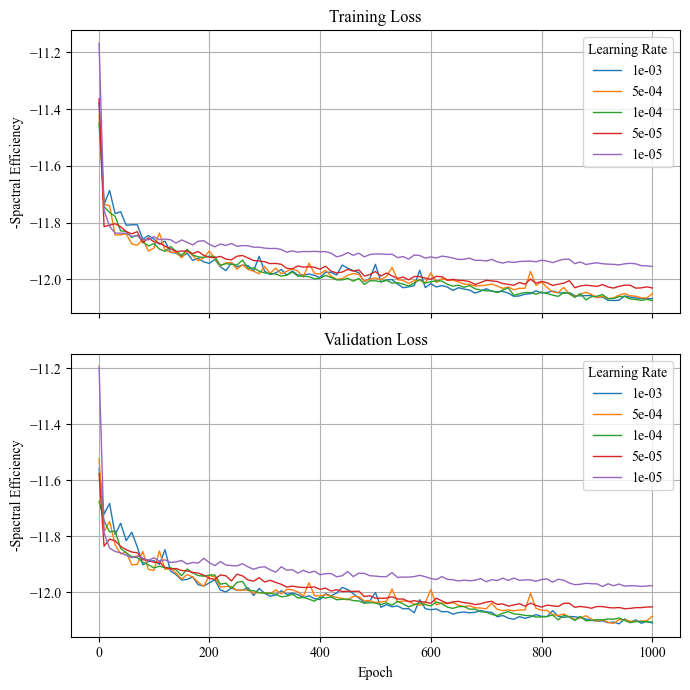

In [4]:
# Times New Roman 폰트 적용
mpl.font_manager.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf')
plt.rcParams['font.family'] = 'Times New Roman'

# 에포크 1번과 에포크 번호가 10의 배수인 데이터만 선택합니다.
df_filtered = df[(df['epoch'] % 10 == 0) | (df['epoch'] == 1)]

# 고유 learning rate 값 추출
lr_values = df_filtered['lr'].unique()

# 2행 1열 서브플롯 생성 (x축 공유)
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

# 첫 번째 서브플롯: Training Loss
for lr in lr_values:
    subset = df_filtered[df_filtered['lr'] == lr]
    axes[0].plot(subset['epoch'], subset['train_loss'], label=f"{lr:.0e}", linewidth=1)
axes[0].set_title("Training Loss")
axes[0].set_ylabel("-Spactral Efficiency")
axes[0].legend(title="Learning Rate")
axes[0].grid(True)

# 두 번째 서브플롯: Validation Loss
for lr in lr_values:
    subset = df_filtered[df_filtered['lr'] == lr]
    axes[1].plot(subset['epoch'], subset['val_loss'], label=f"{lr:.0e}", linewidth=1)
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("-Spactral Efficiency")
axes[1].legend(title="Learning Rate")
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join('result', 'loss_plot.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('result', 'loss_plot.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('result', 'loss_plot.eps'), dpi=300, bbox_inches='tight')
plt.show()